In [5]:
from IPython.display import display
from PIL import Image
from transformers import set_seed

from common.io import find_project_root
from common.model import extract_answer, load_model, run_model

## Load the model

In [6]:
project_root = find_project_root()
set_seed(42, deterministic=True)

model_config = {
    "path" : "JZPeterPan/MedVLM-R1",
    "hf_cache" : "/data/huggingface_cache"
}

model, processor, generation_config = load_model(model_config)

Hugging Face cache: /data/huggingface_cache
Using attention implementation: sdpa
Using device: cuda
Using dtype: torch.bfloat16


Some parameters are on the meta device because they were offloaded to the disk and cpu.


Model and processor loaded successfully.


## Load VQA examples

In [7]:
all_questions = [
    {
        "image": [project_root / "data/OmniMedVQA/sample_mri/images/mod-mri_000031.png"],
        "problem": "What type of diagnostic tool produced this image? A)Angiography, B)Endoscopy, C)X-ray, D)MRI",
        "solution": "D",
        "answer": "MRI"
    },
    {
        "image": [project_root / "result/MedVLM-R1/debug_bias_field_attack/attacked_image/attacked_image_1000.png"],
        "problem": "What type of diagnostic tool produced this image? A)Angiography, B)Endoscopy, C)X-ray, D)MRI",
        "solution": "D",
        "answer": "MRI"
    },
]

## Run inference 

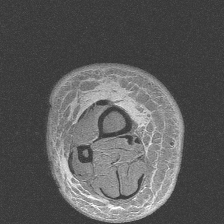

What type of diagnostic tool produced this image? A)Angiography, B)Endoscopy, C)X-ray, D)MRI
Model Answer: D
Model Thought: The image appears to be a cross-sectional view of a medical scan, which is characteristic of Magnetic Resonance Imaging (MRI).
Groundtruth Solution: D


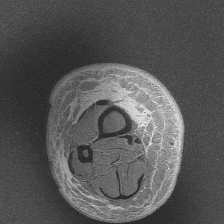

What type of diagnostic tool produced this image? A)Angiography, B)Endoscopy, C)X-ray, D)MRI
Model Answer: D
Model Thought: The image appears to be a scanning electron microscope (SEM) image, which is commonly used to observe the surface and internal structures of biological specimens, including cells and tissues.
Groundtruth Solution: D

Final Score: 2/2


In [8]:
for i, question in enumerate(all_questions):

    output_text = run_model(
        question=question["problem"],
        image=question["image"][0],
        model=model,
        processor=processor,
        generation_config=generation_config
    )
    
    display(Image.open(question["image"][0]))
    
    print(question["problem"])
    
    model_answer = extract_answer(output_text, tag="answer")
    model_thought = extract_answer(output_text, tag="think")
    
    print(f"Model Answer: \033[94m{model_answer}\033[0m")
    print(f"Model Thought: \033[94m{model_thought}\033[0m")
    print(f"Groundtruth Solution: \033[92m{question['solution']}\033[0m")
        